# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR

In [3]:
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [4]:
import shap

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
from platform import python_version

print(python_version())



3.10.12


In [4]:
!which python3

/usr/bin/python3


In [8]:
print(np.__version__)

1.26.3


# Load dataset

In [7]:
tt_set = pd.read_pickle("pickle_files/training_data_bbd.pkl")

In [8]:
tt_set.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,s100,0,0,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [9]:
tt_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 251242 entries, Line to BBD
dtypes: float64(4), int64(251237), object(1)
memory usage: 4.7+ GB


In [10]:
#Final_data= Final_data.drop(['new_line'], axis=1)
tt_set.set_index('Line', inplace=True)
tt_set.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,0,0,0,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,0,0,0,0,0,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [18]:
prt = Final_data.iloc[:, 251237:]
prt.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [11]:
full_pheno = tt_set.iloc[:, 251229:]
full_pheno.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,
s100,9.5000,6.26667,154.700,5.66667,1,0,0,0,0,0,1,61
s100,10.2200,7.19333,130.000,1.80000,0,1,0,0,0,0,1,37
s100,10.2133,4.00000,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,10.3667,7.76667,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,11.8200,7.78667,73.000,2.60000,0,1,0,0,0,0,1,42


In [32]:
snps_loc= Final_data.drop(['BBD', 'LL',	'LW', 'MD',	'PLH', 'PRT'], axis=1)
snps_loc.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,0,2,2,0,2,0,0,0,0,1


In [33]:
snps_all= Final_data.drop(['MD', 'PRT'], axis=1)
snps_all.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52267177,Chr20_52267897,Chr20_52270629,BBD,LL,LW,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,61.0,9.5000,6.26667,154.700,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,37.0,10.2200,7.19333,130.000,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,77.0,10.3667,7.76667,111.733,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,42.0,11.8200,7.78667,73.000,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,2,0,0,62.0,14.2800,10.22000,95.700,0,0,1


In [ ]:
# Split training set into training and validation

In [52]:
X_train, X_test, y_train, y_test = train_test_split(snps, prt, test_size=0.2, random_state=42)

In [142]:
xgbreg = xgb.XGBRegressor(n_jobs =-1 , gamma= 1.0, learning_rate = 0.1, max_depth=7, n_estimators= 200)

In [143]:
xgbreg.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=1.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)

In [144]:
y_pred_xgboost = xgbreg.predict(X_test)

In [145]:
r2_score(y_test, y_pred_xgboost)

-0.15247130393981934

In [146]:
mse = mean_squared_error(y_test, y_pred_xgboost)

In [147]:
rmse = np.sqrt(mse)
print(rmse)

26.116685046019313


# Define all functions

In [6]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}


In [7]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [8]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [9]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [10]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [25]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [12]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# GWAS dataset

In [13]:
#Load file
genotype = pd.read_csv('../gwas_bbd/top_10percent_snps.012', sep='\t', header=None)
genotype.info()

FileNotFoundError: [Errno 2] No such file or directory: '../gwas_bbd/top_10percent_snps.012'

In [13]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,37675,37676,37677,37678,37679,37680,37681,37682,37683,37684
0,0,0,0,0,0,1,0,1,2,0,...,1,2,0,0,0,0,0,0,0,0
1,1,0,0,0,1,1,1,1,0,0,...,1,0,2,1,0,0,0,0,0,0
2,2,0,0,0,0,2,0,1,1,0,...,0,2,0,0,0,0,0,0,0,0
3,3,1,0,2,0,2,1,1,1,0,...,0,0,0,1,2,0,0,0,0,1
4,4,0,0,0,0,1,0,1,1,0,...,0,0,0,0,0,2,2,0,1,0


In [14]:
genotype.set_index(genotype.columns[0], inplace =True)
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,37675,37676,37677,37678,37679,37680,37681,37682,37683,37684
0,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,1,0,1,2,0,0,...,1,2,0,0,0,0,0,0,0,0
1,0,0,0,1,1,1,1,0,0,0,...,1,0,2,1,0,0,0,0,0,0
2,0,0,0,0,2,0,1,1,0,0,...,0,2,0,0,0,0,0,0,0,0
3,1,0,2,0,2,1,1,1,0,0,...,0,0,0,1,2,0,0,0,0,1
4,0,0,0,0,1,0,1,1,0,0,...,0,0,0,0,0,2,2,0,1,0


In [15]:
column_names = pd.read_csv('../gwas_bbd/id_names_top15.txt', sep=' ', header=None)

In [16]:
column_names.head

<bound method NDFrame.head of                     0
0          Chr1_24345
1          Chr1_47731
2         Chr1_110522
3         Chr1_121593
4         Chr1_122144
...               ...
37679  Chr20_52106297
37680  Chr20_52108115
37681  Chr20_52158573
37682  Chr20_52225633
37683  Chr20_52247340

[37684 rows x 1 columns]>

In [17]:
genotype.columns = column_names
genotype.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1311 entries, 0 to 1310
Columns: 37684 entries, ('Chr1_24345',) to ('Chr20_52247340',)
dtypes: int64(37684)
memory usage: 376.9 MB


In [18]:
genotype.head()

,"(Chr1_24345,)","(Chr1_47731,)","(Chr1_110522,)","(Chr1_121593,)","(Chr1_122144,)","(Chr1_122475,)","(Chr1_123323,)","(Chr1_123617,)","(Chr1_124994,)","(Chr1_130043,)",...,"(Chr20_51895489,)","(Chr20_51977670,)","(Chr20_51998773,)","(Chr20_52020557,)","(Chr20_52102670,)","(Chr20_52106297,)","(Chr20_52108115,)","(Chr20_52158573,)","(Chr20_52225633,)","(Chr20_52247340,)"
0,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,1,0,1,2,0,0,...,1,2,0,0,0,0,0,0,0,0
1,0,0,0,1,1,1,1,0,0,0,...,1,0,2,1,0,0,0,0,0,0
2,0,0,0,0,2,0,1,1,0,0,...,0,2,0,0,0,0,0,0,0,0
3,1,0,2,0,2,1,1,1,0,0,...,0,0,0,1,2,0,0,0,0,1
4,0,0,0,0,1,0,1,1,0,0,...,0,0,0,0,0,2,2,0,1,0


In [19]:
#Adding row names
rows= pd.read_csv('../gwas_bbd/top_15percent_indv.txt', header=None)
rows.head()

,0
0,s63
1,s64
2,s66
3,s70
4,s71


In [20]:
genotype.index = rows
genotype.head()

,"(Chr1_24345,)","(Chr1_47731,)","(Chr1_110522,)","(Chr1_121593,)","(Chr1_122144,)","(Chr1_122475,)","(Chr1_123323,)","(Chr1_123617,)","(Chr1_124994,)","(Chr1_130043,)",...,"(Chr20_51895489,)","(Chr20_51977670,)","(Chr20_51998773,)","(Chr20_52020557,)","(Chr20_52102670,)","(Chr20_52106297,)","(Chr20_52108115,)","(Chr20_52158573,)","(Chr20_52225633,)","(Chr20_52247340,)"
"(s63,)",0,0,0,0,1,0,1,2,0,0,...,1,2,0,0,0,0,0,0,0,0
"(s64,)",0,0,0,1,1,1,1,0,0,0,...,1,0,2,1,0,0,0,0,0,0
"(s66,)",0,0,0,0,2,0,1,1,0,0,...,0,2,0,0,0,0,0,0,0,0
"(s70,)",1,0,2,0,2,1,1,1,0,0,...,0,0,0,1,2,0,0,0,0,1
"(s71,)",0,0,0,0,1,0,1,1,0,0,...,0,0,0,0,0,2,2,0,1,0


In [21]:
genotype.to_csv('genotype_top15_percent_bbd.txt', sep ='\t', index = True)

In [22]:
!sed 's/[,()\x27]//g'  genotype_top15_percent_bbd.txt > genotype_top15_percent_bbd_new.txt

In [23]:
#Load the genotype data
genotype_new = pd.read_csv('genotype_top15_percent_bbd_new.txt', sep = '\t')
genotype_new.head()

,Unnamed: 0,Chr1_24345,Chr1_47731,Chr1_110522,Chr1_121593,Chr1_122144,Chr1_122475,Chr1_123323,Chr1_123617,Chr1_124994,...,Chr20_51895489,Chr20_51977670,Chr20_51998773,Chr20_52020557,Chr20_52102670,Chr20_52106297,Chr20_52108115,Chr20_52158573,Chr20_52225633,Chr20_52247340
0,s63,0,0,0,0,1,0,1,2,0,...,1,2,0,0,0,0,0,0,0,0
1,s64,0,0,0,1,1,1,1,0,0,...,1,0,2,1,0,0,0,0,0,0
2,s66,0,0,0,0,2,0,1,1,0,...,0,2,0,0,0,0,0,0,0,0
3,s70,1,0,2,0,2,1,1,1,0,...,0,0,0,1,2,0,0,0,0,1
4,s71,0,0,0,0,1,0,1,1,0,...,0,0,0,0,0,2,2,0,1,0


In [24]:
genotype_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Columns: 37685 entries, Unnamed: 0 to Chr20_52247340
dtypes: int64(37684), object(1)
memory usage: 376.9+ MB


In [25]:
#Setting the index and naming the index column 
genotype_new = genotype_new.rename(columns={genotype_new.columns[0]: 'Line'})
genotype_new.set_index(genotype_new.columns[0])

,Chr1_24345,Chr1_47731,Chr1_110522,Chr1_121593,Chr1_122144,Chr1_122475,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,...,Chr20_51895489,Chr20_51977670,Chr20_51998773,Chr20_52020557,Chr20_52102670,Chr20_52106297,Chr20_52108115,Chr20_52158573,Chr20_52225633,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s63,0,0,0,0,1,0,1,2,0,0,...,1,2,0,0,0,0,0,0,0,0
s64,0,0,0,1,1,1,1,0,0,0,...,1,0,2,1,0,0,0,0,0,0
s66,0,0,0,0,2,0,1,1,0,0,...,0,2,0,0,0,0,0,0,0,0
s70,1,0,2,0,2,1,1,1,0,0,...,0,0,0,1,2,0,0,0,0,1
s71,0,0,0,0,1,0,1,1,0,0,...,0,0,0,0,0,2,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s2894,0,0,1,1,0,0,1,0,1,0,...,1,0,0,0,0,2,0,0,0,0
s2895,0,0,0,0,1,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
s2896,0,0,1,0,0,1,1,0,0,0,...,0,2,0,1,0,0,0,0,0,0


In [26]:
full_pheno.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LL                 2536 non-null   float64
 1   LW                 2536 non-null   float64
 2   PLH                2536 non-null   float64
 3   VBN                2536 non-null   float64
 4   BeiJing_2013       2536 non-null   int64  
 5   HeNan_2014         2536 non-null   int64  
 6   HeNan_2015         2536 non-null   int64  
 7   HeiLongJiang_2014  2536 non-null   int64  
 8   HeiLongJiang_2015  2536 non-null   int64  
 9   improved_cultivar  2536 non-null   int64  
 10  landrace           2536 non-null   int64  
 11  BBD                2536 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 257.6+ KB


In [27]:
gwas_data = pd.merge(genotype_new, full_pheno, on='Line', how='outer', indicator=False)
gwas_data.head()

,Line,Chr1_24345,Chr1_47731,Chr1_110522,Chr1_121593,Chr1_122144,Chr1_122475,Chr1_123323,Chr1_123617,Chr1_124994,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s100,0,0,0,0,2,0,1,1,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
1,s100,0,0,0,0,2,0,1,1,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
2,s100,0,0,0,0,2,0,1,1,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
3,s101,0,0,1,0,0,0,0,0,1,...,58.000,2.60000,0,0,0,0,1,0,1,53
4,s1014,0,0,1,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77


In [28]:
gwas_data = gwas_data.set_index('Line')
gwas_data.head()

,Chr1_24345,Chr1_47731,Chr1_110522,Chr1_121593,Chr1_122144,Chr1_122475,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,0,1,1,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,2,0,1,1,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,2,0,1,1,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s101,0,0,1,0,0,0,0,0,1,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
s1014,0,0,1,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77


In [29]:
gwas_data= gwas_data.drop(['index'], axis=1)

KeyError: "['index'] not found in axis"

In [30]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 37696 entries, Chr1_24345 to BBD
dtypes: float64(4), int64(37692)
memory usage: 729.4+ MB


In [31]:
gwas_data.head()

,Chr1_24345,Chr1_47731,Chr1_110522,Chr1_121593,Chr1_122144,Chr1_122475,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,0,1,1,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,2,0,1,1,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,2,0,1,1,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s101,0,0,1,0,0,0,0,0,1,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
s1014,0,0,1,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77


# GWAS all traits

In [8]:
#gwas_data.to_pickle("GWAS_top15percent_bbd_data.pkl")
gwas_data = pd.read_pickle("../pickle_files/GWAS_top10percent_bbd_data.pkl")
gwas_data.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,1,1,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,1,1,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s101,0,0,0,0,0,1,0,0,0,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
s1014,0,0,0,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77


In [9]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 25135 entries, Chr1_24345 to BBD
dtypes: float64(4), int64(25131)
memory usage: 486.3+ MB


In [10]:
gwas_y = gwas_data.iloc[:, 37695:]
gwas_y.head()

""
Line
s100
s100
s100
s101
s1014


In [11]:
gwas_all= gwas_data.drop(['BBD'], axis=1)
gwas_all.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


In [12]:
gwas_all_dupe= gwas_data.drop(['BBD'], axis=1)
gwas_all_dupe.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


# Run models

In [148]:
X_train, X_test, y_train, y_test = train_test_split(gwas_all, gwas_y, test_size=0.1, random_state=42)

In [149]:
X_train.head()

,Chr1_24345,Chr1_47731,Chr1_110522,Chr1_121593,Chr1_122144,Chr1_122475,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2502,1,0,0,0,2,0,1,1,0,0,...,3.82667,89.0,1.2,0,0,1,0,0,1,0
s286,0,0,0,1,1,0,0,0,0,0,...,3.18667,86.6,3.4,0,0,1,0,0,1,0
s382,0,0,1,0,1,0,1,0,0,0,...,7.96000,95.0,4.0,0,1,0,0,0,0,1
s789,1,0,0,0,2,0,1,1,1,1,...,6.97333,35.0,1.6,0,0,1,0,0,1,0
s691,0,0,1,1,0,0,1,0,0,0,...,6.00667,61.0,3.4,0,0,1,0,0,1,0


In [150]:
X_train = X_train.to_numpy()

In [151]:
y_train = y_train.to_numpy()

In [152]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


In [13]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.3566826912086143), ('colsample_bytree', 0.9865011188018822), ('gamma', 0.09857984263265858), ('learning_rate', 0.04084699329478003), ('max_delta_step', 15), ('max_depth', 48), ('min_child_weight', 10), ('n_estimators', 175), ('reg_alpha', 0.008107929561612038), ('reg_lambda', 0.005093853908688839), ('subsample', 0.5066509197597943)])

In [28]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.633683511069695
RMSE for dataset is:6.142632727783613& mean of this fold is 45.55511811023622
this is 13.483957418175072% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6636472934226348
RMSE for dataset is:6.400906548036261& mean of this fold is 46.57874015748032
this is 13.74212038881929% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6675846124333534
RMSE for dataset is:6.013980206312633& mean of this fold is 45.26377952755905
this is 13.286517982111931% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6638676694826524
RMSE for dataset is:6.347331585034509& mean of this fold is 46.531496062992126
this is 13.640935972576068% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7457556911764605
RMSE for datase

In [153]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6862071810955939
RMSE for dataset is:5.824780301478398& mean of this fold is 46.574803149606296
this is 12.506290757189461% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6384041610325772
RMSE for dataset is:6.43066830144401& mean of this fold is 45.94094488188976
this is 13.99768402233935% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6489926807375193
RMSE for dataset is:5.741358507569176& mean of this fold is 45.874015748031496
this is 12.515491425700057% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5441232653837496
RMSE for dataset is:6.542763494109309& mean of this fold is 45.874015748031496
this is 14.262460757842124% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.558020612077084
RMSE for datas

In [13]:
#pickle.dump(best_xgbr_model, open("gwas_top10_allfeats_xgbr_bbd.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_allfeats_xgbr_bbd.pickle.dat", "rb"))

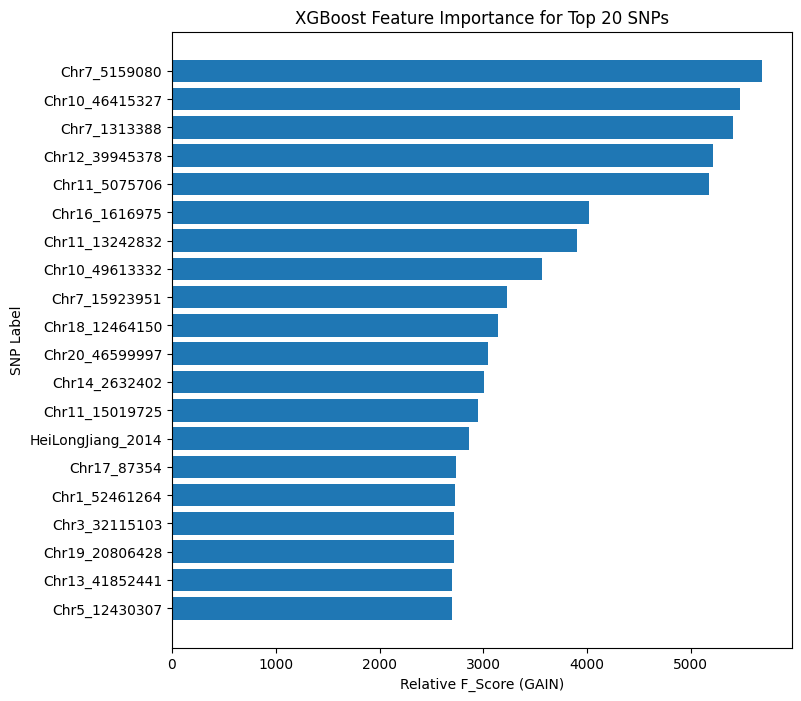

In [30]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_all_dupe, top_n=20)

In [31]:
explainer = shap.Explainer(best_xgbr_model)

In [32]:
shap_values = explainer(gwas_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

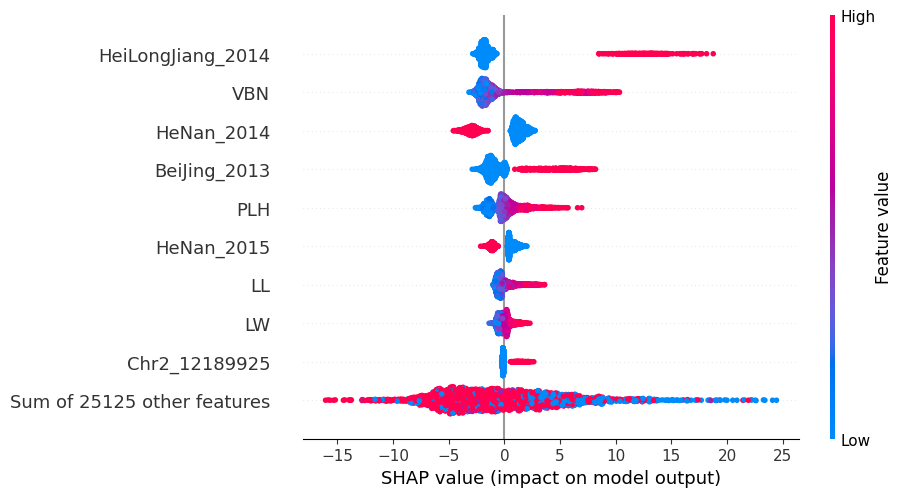

In [33]:
shap.plots.beeswarm(shap_values, show=False)

In [14]:
holdout_data = pd.read_pickle("../pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [15]:
holdout_data = holdout_data.set_index('Line')

In [16]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [17]:
X_holdout = holdout_data.iloc[:, 0:251240]

In [18]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [19]:
y_holdout = holdout_data.iloc[:, 251240:]

In [20]:
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [21]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [22]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 25134 entries, Chr1_24345 to landrace
dtypes: float64(4), int64(25130)
memory usage: 121.6+ MB


In [23]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.78
RMSE of Holdout: 6.51
Mean of Holdout: 47.16
This is 13.81% of the mean pheno data
0 45 46.1129
1 39 56.21259
2 62 65.4956
3 47 52.445747
4 42 40.08104


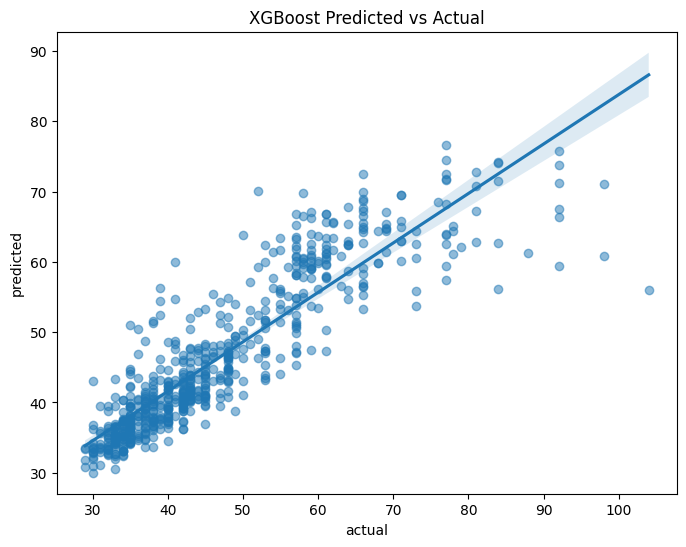

In [26]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [45]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 45 46.1129
1 39 56.21259
2 62 65.4956
3 47 52.445747
4 42 40.08104
5 40 39.59681


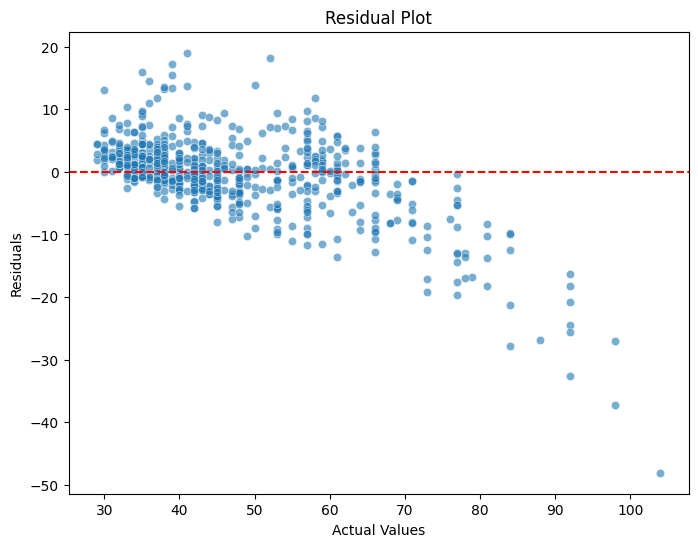

In [46]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [47]:
#### RF models

In [48]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 6), ('n_estimators', 370)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 6), ('n_estimators', 370)])

In [49]:
best_rfr_model = eval_k_fold(best_rfreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.151321296908073
RMSE for dataset is:11.338901908283976& mean of this fold is 44.275590551181104
this is 25.609826469003465% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.846780637059767
RMSE for dataset is:12.78959827996359& mean of this fold is 46.425196850393704
this is 27.54882940222822% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.333101684740027
RMSE for dataset is:11.491707688069122& mean of this fold is 45.93307086614173
this is 25.01837449875338% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.094627331117481
RMSE for dataset is:12.11135505194299& mean of this fold is 46.74803149606299
this is 25.907732720174494% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.980916396074354
RMSE for d

In [50]:
pickle.dump(best_rfr_model, open("gwas_top10_allfeats_rfr_bbd.pickle.dat", "wb"))

In [29]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_allfeats_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.17
RMSE of Holdout: 12.66
Mean of Holdout: 47.16
This is 26.85% of the mean pheno data
0 45 50.04613135334962
1 39 47.835932328565534
2 62 48.29526548936985
3 47 50.31002155352882
4 42 45.46432918516893


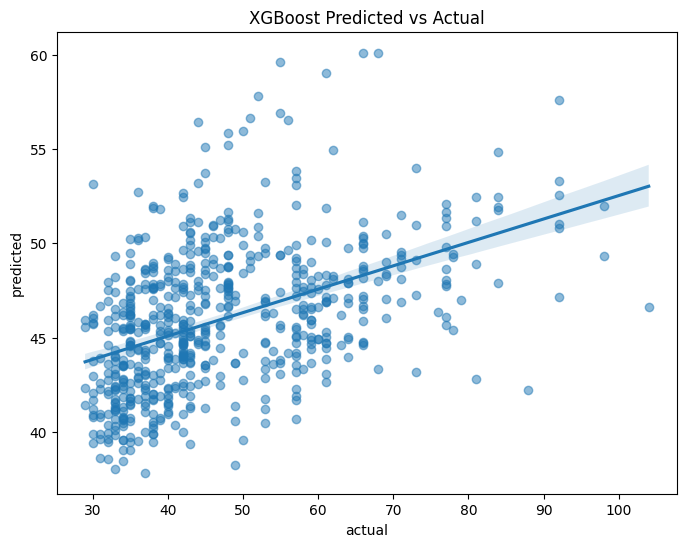

In [30]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [52]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [53]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7073045893609323
RMSE for dataset is:6.166182152114902& mean of this fold is 45.28740157480315
this is 13.615667796550337% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7558870259036854
RMSE for dataset is:6.3234148166589055& mean of this fold is 46.0
this is 13.746553949258491% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.744115626845784
RMSE for dataset is:6.477611133894432& mean of this fold is 46.76377952755905
this is 13.851769893998869% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7713043922133204
RMSE for dataset is:6.168332867346944& mean of this fold is 46.8503937007874
this is 13.166021414337175% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6470617100708126
RMSE for dataset is:7.295625

In [54]:
pickle.dump(best_svr_model, open("gwas_top10_allfeats_svr_bbd.pickle.dat", "wb"))

In [27]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_allfeats_svr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.75
RMSE of Holdout: 6.96
Mean of Holdout: 47.16
This is 14.76% of the mean pheno data
0 45 48.15978769512046
1 39 50.735515565353296
2 62 70.5108033718401
3 47 60.96367355480302
4 42 40.38786437864624


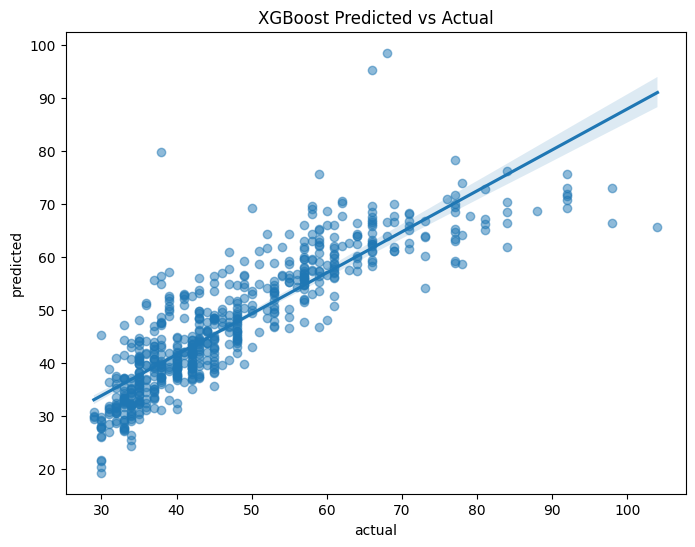

In [28]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [31]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 25135 entries, Chr1_24345 to BBD
dtypes: float64(4), int64(25131)
memory usage: 486.3+ MB


In [32]:
gwas_snps = gwas_data.iloc[:, 0:25123]
gwas_snps.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_51891016,Chr20_51891017,Chr20_51977670,Chr20_51998773,Chr20_52020557,Chr20_52102670,Chr20_52108115,Chr20_52158573,Chr20_52225633,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,2,0,0,0,0


In [33]:
gwas_snps_dupe = gwas_data.iloc[:, 0:25123]
gwas_snps_dupe.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_51891016,Chr20_51891017,Chr20_51977670,Chr20_51998773,Chr20_52020557,Chr20_52102670,Chr20_52108115,Chr20_52158573,Chr20_52225633,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,2,0,0,0,0


In [34]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


# Run models

In [62]:
X_train, X_test, y_train, y_test = train_test_split(gwas_snps, gwas_y, test_size=0.1, random_state=42)

In [63]:
X_train.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_51891016,Chr20_51891017,Chr20_51977670,Chr20_51998773,Chr20_52020557,Chr20_52102670,Chr20_52108115,Chr20_52158573,Chr20_52225633,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s2502,1,0,0,1,1,0,0,2,0,0,...,2,0,0,0,0,0,0,0,1,0
s286,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
s382,0,0,0,1,0,0,0,0,0,2,...,1,0,0,0,0,0,0,0,1,0
s789,1,0,0,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
s691,0,0,1,1,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0


In [64]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [65]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])


OrderedDict([('colsample_bylevel', 0.9132100359267209), ('colsample_bytree', 0.7679711803126804), ('gamma', 2.428808912219129e-07), ('learning_rate', 0.03511167856740689), ('max_delta_step', 3), ('max_depth', 8), ('min_child_weight', 4), ('n_estimators', 197), ('reg_alpha', 0.023358352781682152), ('reg_lambda', 2.1396512525873352e-07), ('scale_pos_weight', 0.001760608876847004), ('subsample', 0.15990388740095085)])


In [67]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.605157384976112
RMSE for dataset is:11.286103680636966& mean of this fold is 45.039370078740156
this is 25.058307123092565% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.83299001991954
RMSE for dataset is:11.306696975050539& mean of this fold is 44.92913385826772
this is 25.165624182113888% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -11.230584056453248
RMSE for dataset is:13.08991737759114& mean of this fold is 46.51574803149607
this is 28.140829571799824% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.837632381934599
RMSE for dataset is:11.834344810666746& mean of this fold is 46.476377952755904
this is 25.46313919448838% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -12.1180535141415
RMSE for d

In [68]:
pickle.dump(best_xgbr_model, open("gwas_top10_onlysnps_xgbr_bbd.pickle.dat", "wb"))

In [35]:
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlysnps_xgbr_bbd.pickle.dat", "rb"))

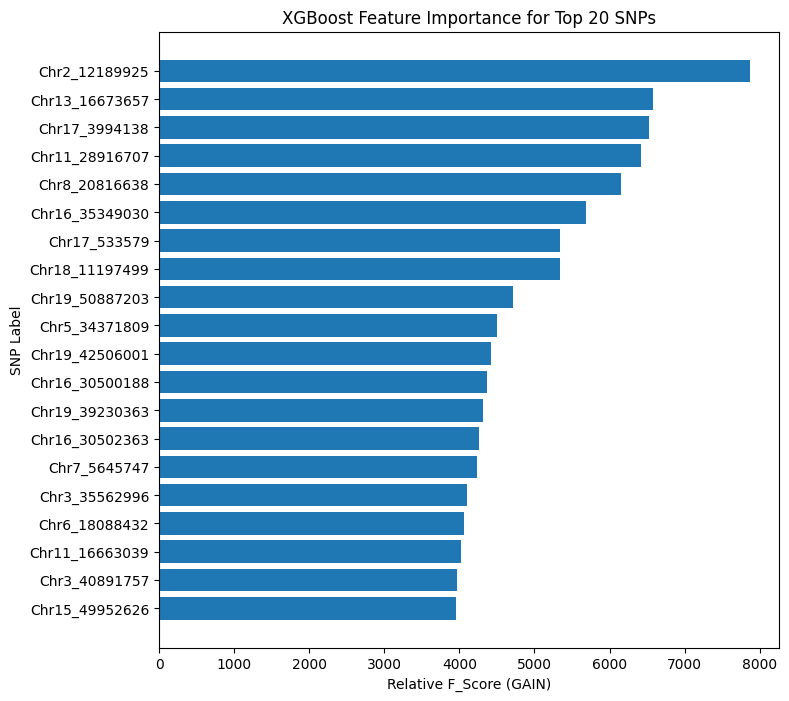

In [69]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_snps_dupe , top_n=20)

In [70]:
explainer = shap.Explainer(best_xgbr_model)

In [71]:
shap_values = explainer(gwas_snps_dupe)

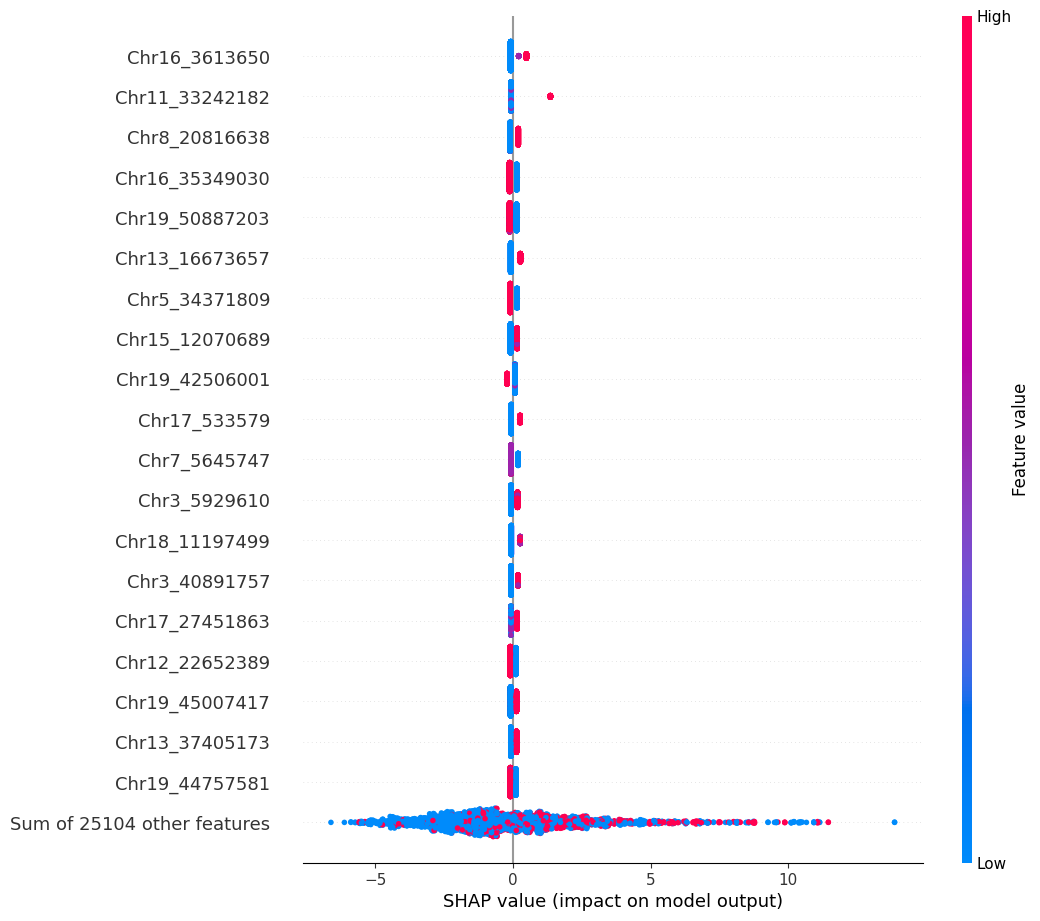

In [72]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [73]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [74]:
holdout_data = holdout_data.set_index('Line')

In [36]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [37]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [38]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [39]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 25123 entries, Chr1_24345 to Chr20_52247340
dtypes: int64(25123)
memory usage: 121.5+ MB


In [40]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.12
RMSE of Holdout: 13.03
Mean of Holdout: 47.16
This is 27.63% of the mean pheno data
0 45 48.737537
1 39 45.80834
2 62 45.80834
3 47 45.22075
4 42 46.92271


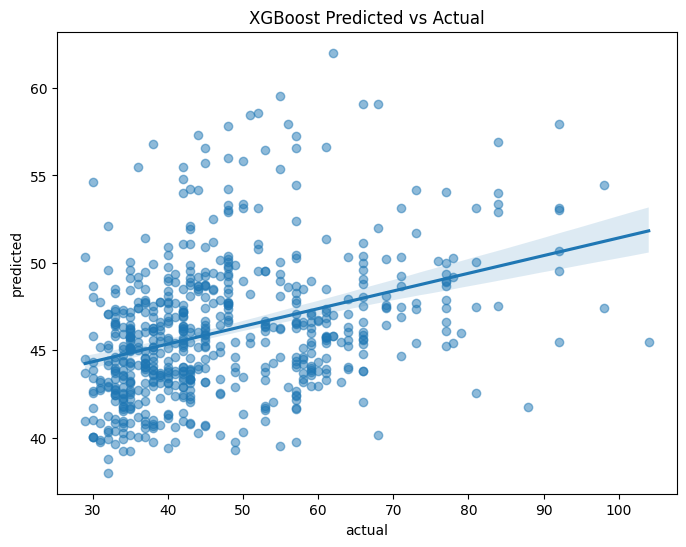

In [41]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [103]:
#### RF models

In [81]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 8), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 2), ('n_estimators', 500)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 8), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 2), ('n_estimators', 500)])

In [82]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.788674136634027
RMSE for dataset is:11.57814317391547& mean of this fold is 45.173228346456696
this is 25.630541800370654% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -15.721669790240497
RMSE for dataset is:12.773238803499142& mean of this fold is 47.28346456692913
this is 27.014176986584364% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.247977228224762
RMSE for dataset is:12.721846893762079& mean of this fold is 46.05118110236221
this is 27.625451919428638% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -13.480227888757305
RMSE for dataset is:12.021434668266828& mean of this fold is 45.70866141732284
this is 26.300124080445947% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -11.807701598319087
RMSE f

In [83]:
pickle.dump(best_rfr_model, open("gwas_top10_onlysnps_rfr_bbd.pickle.dat", "wb"))

In [44]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlysnps_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.09
RMSE of Holdout: 13.22
Mean of Holdout: 47.16
This is 28.04% of the mean pheno data
0 45 47.67998163816889
1 39 45.32289569196998
2 62 45.32289569196998
3 47 48.6217951233918
4 42 45.63081730557425


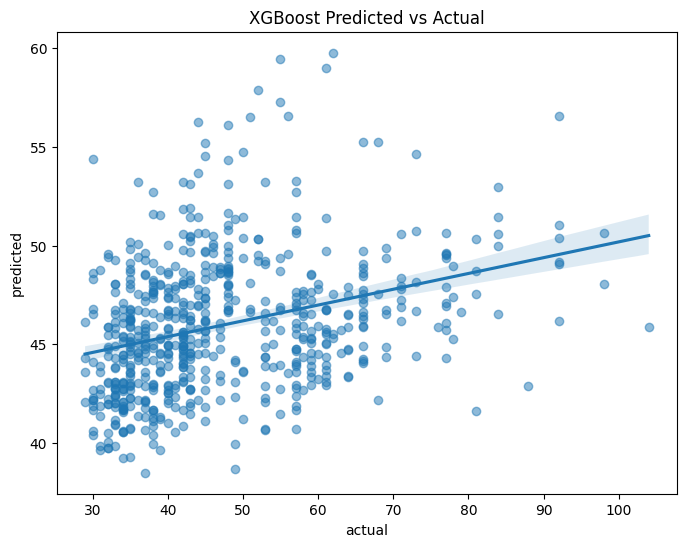

In [45]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [85]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 3), ('kernel', 'sigmoid')])


In [86]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -17.483413778022133
RMSE for dataset is:12.41338419178914& mean of this fold is 46.47244094488189
this is 26.711280792226717% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -17.35728355300357
RMSE for dataset is:11.788269362898596& mean of this fold is 45.53543307086614
this is 25.888123968323047% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -20.719767294769348
RMSE for dataset is:13.165659594177557& mean of this fold is 47.031496062992126
this is 27.993282579282603% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -14.15513810323338
RMSE for dataset is:11.28490265532283& mean of this fold is 45.854330708661415
this is 24.6103311964626% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -23.83741074448103
RMSE for d

In [87]:
pickle.dump(best_svr_model, open("gwas_top10_onlysnps_svr_bbd.pickle.dat", "wb"))

In [42]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlysnps_svr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.01
RMSE of Holdout: 13.78
Mean of Holdout: 47.16
This is 29.23% of the mean pheno data
0 45 44.08635868685816
1 39 42.66737852583081
2 62 42.66737852583081
3 47 42.336404279410495
4 42 42.99986510285707


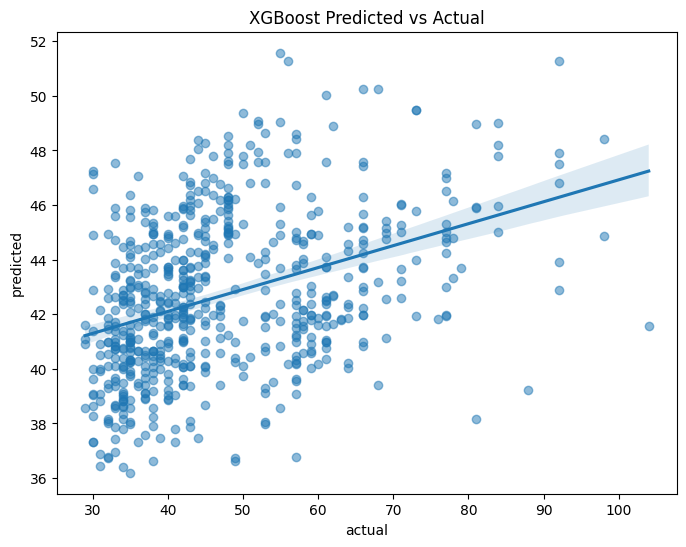

In [43]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [46]:
gwas_loc= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_52158573,Chr20_52225633,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [47]:
gwas_loc_dupe= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_52158573,Chr20_52225633,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [48]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 25130 entries, Chr1_24345 to landrace
dtypes: int64(25130)
memory usage: 486.2+ MB


In [49]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [50]:
# Run models

In [106]:
X_train, X_test, y_train, y_test = train_test_split(gwas_loc, gwas_y, test_size=0.1, random_state=42)

In [107]:
X_train.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_52158573,Chr20_52225633,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2502,1,0,0,1,1,0,0,2,0,0,...,0,1,0,0,0,1,0,0,1,0
s286,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
s382,0,0,0,1,0,0,0,0,0,2,...,0,1,0,0,1,0,0,0,0,1
s789,1,0,0,1,1,1,1,1,1,0,...,0,0,0,0,0,1,0,0,1,0
s691,0,0,1,1,0,0,0,0,0,2,...,0,0,0,0,0,1,0,0,1,0


In [108]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [109]:
print(y_train[~np.isfinite(y_train)])

[]


In [111]:
print("Is there infinity in y?", np.isinf(y_train).any())
print("Is there NaN in y?", np.isnan(y_train).any())
print("Max value in y:", np.max(y_train))
print("Min value in y:", np.min(y_train))

Is there infinity in y? False
Is there NaN in y? False
Max value in y: 117
Min value in y: 21


In [112]:
#set the parameter space for XGBoost regression
xg_space ={'learning_rate': Real(0.01, 0.3, 'log-uniform'),
        'min_child_weight': Integer(1, 10),
        'max_depth': Integer(3, 20),
        'max_delta_step': Integer(0, 10),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-4, 0.3, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

In [113]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, xg_space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.9976011122950389), ('colsample_bytree', 0.7682819210794223), ('gamma', 0.13911039336919284), ('learning_rate', 0.13050480896372257), ('max_delta_step', 6), ('max_depth', 12), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 7.1676921027168875e-06), ('reg_lambda', 2.734248201219664), ('subsample', 0.8002905181769281)])


In [70]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.9976011122950389), ('colsample_bytree', 0.7682819210794223), ('gamma', 0.13911039336919284), ('learning_rate', 0.13050480896372257), ('max_delta_step', 6), ('max_depth', 12), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 7.1676921027168875e-06), ('reg_lambda', 2.734248201219664), ('subsample', 0.8002905181769281)])

OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 2), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('scale_pos_weight', 0.060830282487222144), ('subsample', 0.13556548021189216)])


In [114]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6517570371353484
RMSE for dataset is:6.363515994286916& mean of this fold is 46.57086614173228
this is 13.664156416847382% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6663994571799401
RMSE for dataset is:6.1030845823434134& mean of this fold is 45.98031496062992
this is 13.273255277979512% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6327964442138893
RMSE for dataset is:6.098879097611301& mean of this fold is 44.70472440944882
this is 13.6425829220015% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5742803859232748
RMSE for dataset is:6.908366458543936& mean of this fold is 46.12992125984252
this is 14.97589041964803% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5878309556048702
RMSE for dataset

In [51]:
#pickle.dump(best_xgbr_model, open("gwas_top10_onlyloc_xgbr_bbd.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlyloc_xgbr_bbd.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

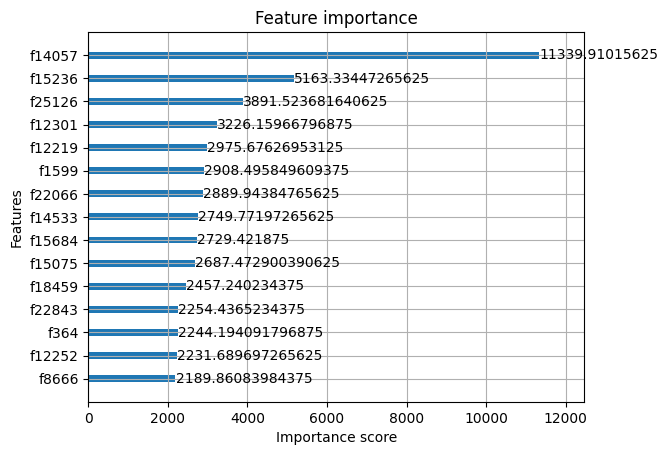

In [116]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

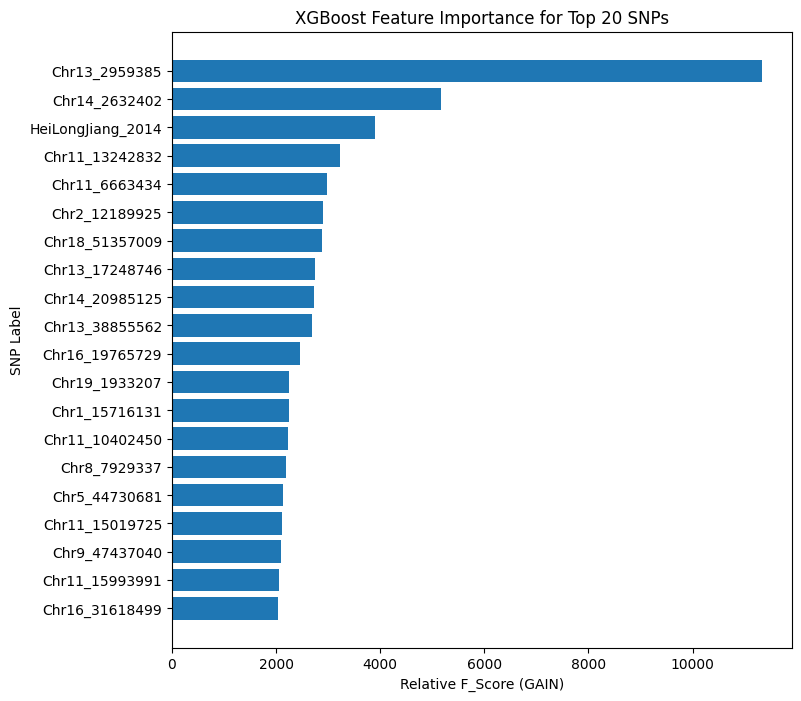

In [117]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_loc_dupe, top_n=20)

In [118]:
explainer = shap.Explainer(best_xgbr_model)

In [119]:
shap_values = explainer(gwas_loc_dupe, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

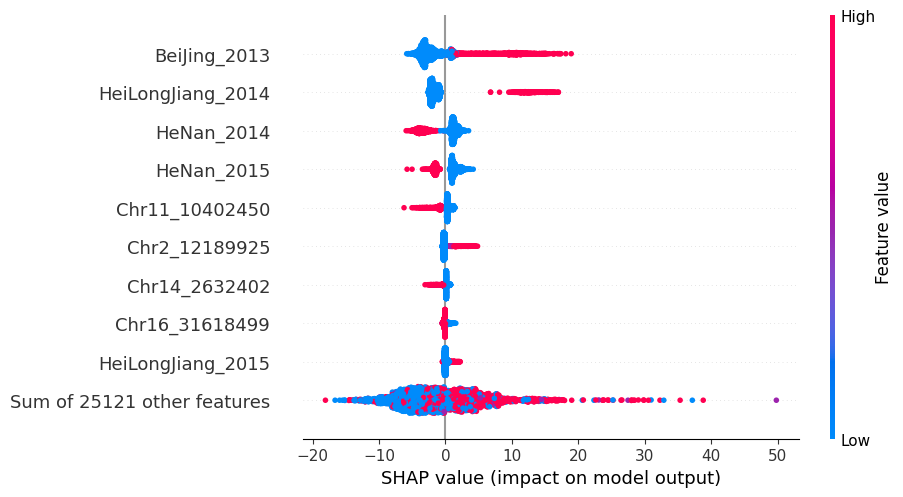

In [120]:
shap.plots.beeswarm(shap_values, show=False)

In [121]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [122]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [52]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [53]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [54]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [55]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 25130 entries, Chr1_24345 to landrace
dtypes: int64(25130)
memory usage: 121.6+ MB


In [56]:
X_holdout.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_52158573,Chr20_52225633,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,1,1,1,0,0,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,1,0,0,1
s1026,0,0,0,1,0,1,0,1,1,0,...,2,0,0,0,0,0,0,1,0,1
s1030,0,0,0,1,0,1,0,1,1,2,...,0,0,0,0,1,0,0,0,0,1


In [57]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.76
RMSE of Holdout: 6.84
Mean of Holdout: 47.16
This is 14.50% of the mean pheno data
0 45 45.781517
1 39 53.93963
2 62 62.236603
3 47 53.121593
4 42 39.703335


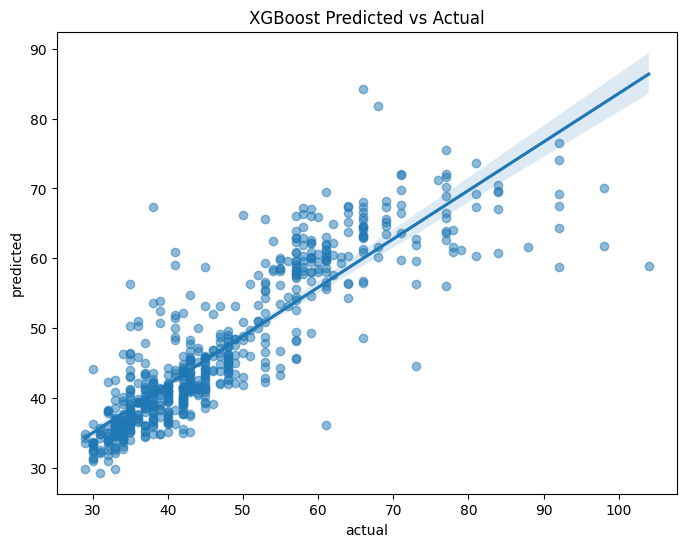

In [58]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [130]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 45 45.781517
1 39 53.93963
2 62 62.236603
3 47 53.121593
4 42 39.703335
5 40 40.994503


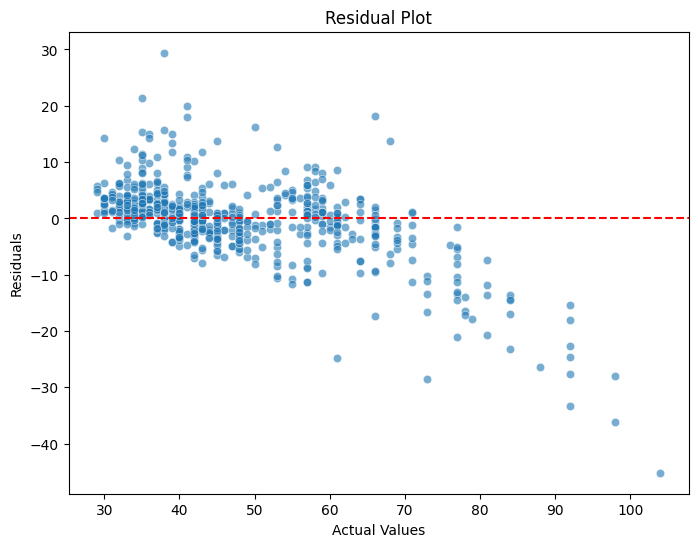

In [131]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [132]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.5952955405322832), ('min_samples_leaf', 10), ('min_samples_split', 4), ('n_estimators', 500)])


In [2]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.5952955405322832), ('min_samples_leaf', 10), ('min_samples_split', 4), ('n_estimators', 500)])

In [135]:
gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.384243446261015
RMSE for dataset is:11.977773514708966& mean of this fold is 45.59448818897638
this is 26.270222543269817% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.804315696033829
RMSE for dataset is:11.952699292379755& mean of this fold is 45.88582677165354
this is 26.048782670651722% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.9444767129776395
RMSE for dataset is:11.375280207910604& mean of this fold is 45.661417322834644
this is 24.91223635807289% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.355568230913807
RMSE for dataset is:11.588506154739358& mean of this fold is 45.188976377952756
this is 25.644542283531948% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.191008457537347
RMSE for

In [136]:
pickle.dump(best_rfr_model, open("gwas_top10_onlyloc_rfr_bbd.pickle.dat", "wb"))

In [61]:
best_rfr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlyloc_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.15
RMSE of Holdout: 12.79
Mean of Holdout: 47.16
This is 27.11% of the mean pheno data
0 45 51.51412165765737
1 39 47.59269468279644
2 62 48.02203532076297
3 47 49.341944140925314
4 42 46.51588979957335


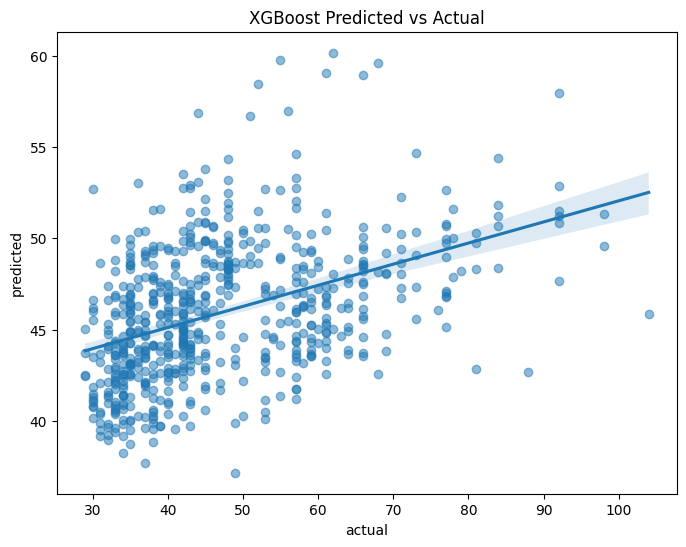

In [62]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [138]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [139]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7100082698685244
RMSE for dataset is:6.885320485981192& mean of this fold is 46.40551181102362
this is 14.837290264182768% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7952339979073227
RMSE for dataset is:5.666794351222267& mean of this fold is 46.10629921259842
this is 12.290716123392158% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6409570683235218
RMSE for dataset is:6.875415745638277& mean of this fold is 46.145669291338585
this is 14.89937376838258% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7842017593542941
RMSE for dataset is:5.679211938443762& mean of this fold is 45.6496062992126
this is 12.440878243766413% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6903108636592815
RMSE for datase

In [140]:
pickle.dump(best_svr_model, open("gwas_top10_onlyloc_svr_bbd.pickle.dat", "wb"))

In [59]:
best_svr_model = pickle.load(open("../pickle_bestmodels/gwas_top10_onlyloc_svr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: 0.73
RMSE of Holdout: 7.21
Mean of Holdout: 47.16
This is 15.29% of the mean pheno data
0 45 55.499775325522656
1 39 50.49993493461381
2 62 70.4999646544432
3 47 58.500020994393346
4 42 39.500016168840965


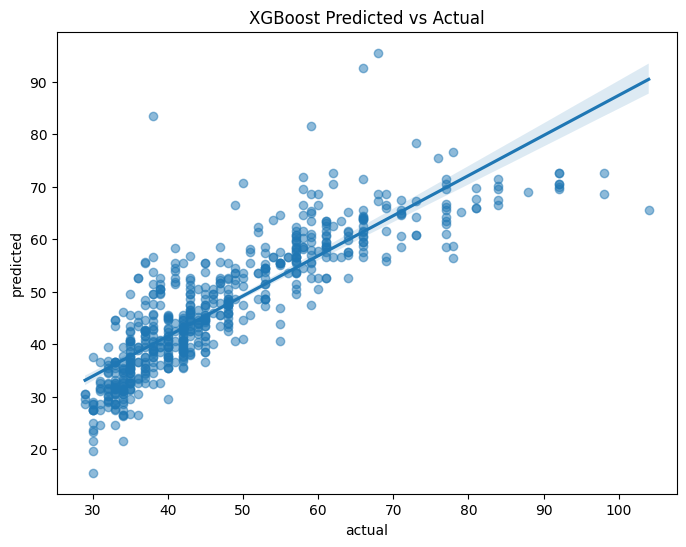

In [60]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)